# Partie 2 — Intégration des Covariables Environnementales
## Ablation Study : Sentinel-2 + Climat + Sol + Topographie

**Ce notebook part directement des CSV existants (pas besoin de relancer la Partie 1)**

### Covariables choisies :
| Type | Variables | Justification |
|---|---|---|
| **Climat** | mean_2m_air_temperature, total_precipitation, dewpoint_2m_temperature | Température et pluie dictent la phénologie ; le dewpoint capte le stress hydrique |
| **Sol** | pH in H2O, Organic Carbon, Texture Class | pH = fertilité ; OC = qualité du sol ; Texture = rétention d'eau |
| **Topographie** | Elevation, Landforms | Altitude et forme de terrain influencent drainage et microclimat |

### 5 configurations d'ablation study :
1. **S2 seul** (baseline)
2. **S2 + Climat**
3. **S2 + Sol**
4. **S2 + Topographie**
5. **S2 + Tout** (toutes covariables)

## 📦 Imports

In [1]:
import ee
import numpy as np
import pandas as pd
import datetime
import math, warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = False

# GEE
ee.Initialize(project='sentinel-2-490309')

print(f'PyTorch : {torch.__version__}')
print(f'GEE     : OK')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

c:\Users\LENOVO\Documents\res n\myenv\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


PyTorch : 2.11.0+cpu
GEE     : OK
GPU     : CPU


## ⚙️ Configuration

In [2]:
PROCESSED_DIR = Path('data/processed')
MODEL_DIR     = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyperparamètres globaux ───────────────────────────────────────────────────
N_BANDS      = 10
N_DATES      = 36
BATCH_SIZE   = 128
LR           = 3e-4
EPOCHS       = 150
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ── Dimensions exactes par configuration ─────────────────────────────────────
# S2_only    : 10 × 36 = 360   features
# S2_climate : 13 × 36 = 468   features  (+Temp, Precip, Dewpoint)
# S2_soil    : 13 × 36 = 468   features  (+pH, OC, Texture)
# S2_topo    : 12 × 36 = 432   features  (+Elevation, Landforms)
# S2_all     : 18 × 36 = 648   features  (+Temp,Precip,Dew,pH,OC,Tex,Elev,LF)

# ── Régularisation adaptée au nombre de features par config ──────────────────
# Observation : S2+soil et S2+all montrent un overfitting sur CA (gap F1 > 7%)
# → dropout et weight_decay renforcés pour les configs à haute dimensionnalité
CONFIG_REGULARIZATION = {
    'S2_only'   : {'dropout': 0.3, 'weight_decay': 1e-4, 'patience': 20},
    'S2_climate': {'dropout': 0.3, 'weight_decay': 1e-4, 'patience': 20},
    'S2_soil'   : {'dropout': 0.4, 'weight_decay': 5e-4, 'patience': 15},
    'S2_topo'   : {'dropout': 0.3, 'weight_decay': 1e-4, 'patience': 20},
    'S2_all'    : {'dropout': 0.4, 'weight_decay': 5e-4, 'patience': 15},
}

# ── Chemins CSV ───────────────────────────────────────────────────────────────
CSV_CA = Path('data/processed/CALIFORNIA_10000x360.csv')
CSV_AR = Path('data/processed/ARKANSAS_S2_WIDE_10000x360.csv')

AOI_CA = ee.Geometry.Rectangle([-122.5, 36.0, -119.0, 40.0])
AOI_AR = ee.Geometry.Rectangle([-94.0,  33.5,  -90.0, 36.5])

LABEL_MAP_AR = {1: 'Soybeans', 2: 'Rice', 3: 'Corn', 5: 'Cotton', 999: 'Others'}
AR_ORDER     = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']

LABEL_MAP_CA = {3: 'Rice', 36: 'Grapes', 69: 'Almonds', 75: 'Pistachios',
                204: 'Alfalfa', 999: 'Others'}
CA_ORDER     = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

CONFIGS = ['S2_only', 'S2_climate', 'S2_soil', 'S2_topo', 'S2_all']

print(f'Device : {DEVICE}')
print(f'CSV CA : {CSV_CA.exists()}')
print(f'CSV AR : {CSV_AR.exists()}')
print()
print(f'{"Config":<15} {"Bandes":>6} {"Features":>9} {"Dropout":>8} {"WD":>8} {"Patience":>9}')
print('-' * 60)
n_bands_map = {'S2_only':10,'S2_climate':13,'S2_soil':13,'S2_topo':12,'S2_all':18}
for cfg in CONFIGS:
    r = CONFIG_REGULARIZATION[cfg]
    nb_ = n_bands_map[cfg]
    print(f'{cfg:<15} {nb_:>6} {nb_*N_DATES:>9} '
          f'{r["dropout"]:>8.1f} {r["weight_decay"]:>8.0e} {r["patience"]:>9}')


Device : cpu
CSV CA : True
CSV AR : True


## 🌍 ÉTAPE 1 — Extraction des covariables via GEE

In [3]:
def extract_covariates_gee(aoi, year=2021, scale=1000, n_dates=36):
    """
    Extrait les covariables environnementales sur la zone d'étude via GEE.
    Retourne un dict :
      cov['climate'] : np.array (36, 3)  — temp, precip, dewpoint
      cov['soil']    : np.array (36, 3)  — ph, oc, texture (statique répété)
      cov['topo']    : np.array (2,)     — elevation, landforms
    """
    print('  Extraction GEE en cours...')
    results = {}

    # Dates des 36 timesteps uniformément répartis sur l'année
    day_step = 365 / n_dates
    dates = []
    for i in range(n_dates):
        doy = int(i * day_step) + 1
        d = datetime.date(year, 1, 1) + datetime.timedelta(days=doy - 1)
        dates.append(d.strftime('%Y-%m-%d'))
    window_days = 5

    # ── CLIMAT : ERA5-Land → 36 moyennes temporelles ─────────────────────────
    print('  Extraction ERA5...')
    era5_full = (
        ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filterBounds(aoi)
        .select(['temperature_2m', 'total_precipitation_sum', 'dewpoint_temperature_2m'])
    )
    count = era5_full.size().getInfo()
    if count == 0:
        raise ValueError(f'ERA5-Land : aucune image trouvée pour {year}.')
    print(f'  ERA5-Land : {count} images')

    def era5_window_mean(date_str):
        d  = datetime.datetime.strptime(date_str, '%Y-%m-%d')
        d0 = (d - datetime.timedelta(days=window_days)).strftime('%Y-%m-%d')
        d1 = (d + datetime.timedelta(days=window_days + 1)).strftime('%Y-%m-%d')
        img = era5_full.filterDate(d0, d1).mean()
        img = img.addBands(
            img.select('temperature_2m').subtract(273.15).rename('temp_c')
        ).addBands(
            img.select('dewpoint_temperature_2m').subtract(273.15).rename('dew_c')
        )
        return img.select(['temp_c', 'total_precipitation_sum', 'dew_c']).reduceRegion(
            reducer=ee.Reducer.mean(), geometry=aoi, scale=scale, maxPixels=1e8
        )

    features = [ee.Feature(None, era5_window_mean(d)) for d in dates]
    fc_info  = ee.FeatureCollection(features).getInfo()

    climate_ts = []
    for feat in fc_info['features']:
        p = feat['properties']
        climate_ts.append([
            p.get('temp_c', 0.0),
            p.get('total_precipitation_sum', 0.0) * 1000,
            p.get('dew_c', 0.0),
        ])
    results['climate'] = np.array(climate_ts, dtype=np.float32)  # (36, 3)
    print(f'  Climat OK: {results["climate"].shape}')

    # ── SOL : OpenLandMap → statique répété ───────────────────────────────────
    soil_ph  = ee.Image('OpenLandMap/SOL/SOL_PH-H2O_USDA-4C1A2A_M/v02').select('b0')
    soil_oc  = ee.Image('OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02').select('b0')
    soil_tex = ee.Image('OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02').select('b0')

    soil_stack = (
        soil_ph.rename('soil_ph')
        .addBands(soil_ph.divide(10).rename('soil_ph_real'))
        .addBands(soil_oc.multiply(5).rename('soil_oc_gkg'))
        .addBands(soil_tex.rename('soil_texture'))
    )
    soil_stats = soil_stack.select(['soil_ph_real', 'soil_oc_gkg', 'soil_texture']).reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi, scale=250, maxPixels=1e9
    ).getInfo()

    soil_vec = np.array([
        soil_stats.get('soil_ph_real', 0.0),
        soil_stats.get('soil_oc_gkg',  0.0),
        soil_stats.get('soil_texture',  0.0),
    ], dtype=np.float32)
    results['soil'] = np.tile(soil_vec, (n_dates, 1)).astype(np.float32)  # (36, 3)
    print(f'  Sol OK: {results["soil"].shape}  valeurs={soil_vec}')

    # ── TOPOGRAPHIE : ALOS DEM ─────────────────────────────────────────────────
    elevation = ee.Image('JAXA/ALOS/AW3D30/V2_2').select('AVE_DSM').rename('elevation')
    landforms = ee.Image('CSP/ERGo/1_0/Global/ALOS_landforms').select('constant').rename('landforms')
    topo_stats = elevation.addBands(landforms).reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi, scale=90, maxPixels=1e9
    ).getInfo()
    results['topo'] = np.array([
        topo_stats.get('elevation', 0.0),
        topo_stats.get('landforms', 0.0),
    ], dtype=np.float32)
    print(f'  Topo OK: {results["topo"]}')

    return results


print('=== Extraction covariables — CALIFORNIA ===')
cov_CA = extract_covariates_gee(AOI_CA)
print('\n=== Extraction covariables — ARKANSAS ===')
cov_AR = extract_covariates_gee(AOI_AR)
print('\n✅ Extraction terminée')

=== Extraction covariables — CALIFORNIA ===
  Extraction GEE en cours...
  Extraction ERA5...
  ERA5-Land : 364 images
  Climat OK: (36, 3)
  Sol OK: (36, 3)  valeurs=[ 6.8227916 23.039877   7.0867066]


c:\Users\LENOVO\Documents\res n\myenv\lib\site-packages\ee\deprecation.py:215: DeprecationWarning: 

Attention required for JAXA/ALOS/AW3D30/V2_2! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by JAXA/ALOS/AW3D30/V4_1

Learn more: https://developers.google.com/earth-engine/datasets/catalog/JAXA_ALOS_AW3D30_V2_2

  warnings.warn(warning, category=DeprecationWarning)


  Topo OK: [752.2221   28.96603]

=== Extraction covariables — ARKANSAS ===
  Extraction GEE en cours...
  Extraction ERA5...
  ERA5-Land : 364 images
  Climat OK: (36, 3)
  Sol OK: (36, 3)  valeurs=[ 5.6635623 19.521746   7.1084204]
  Topo OK: [153.73297   29.030521]

✅ Extraction terminée


## 📊 ÉTAPE 2 — Exploration des covariables

In [4]:
def summarize_covariates(cov, label):
    print(f'\n{"="*55}\n  Covariables — {label}\n{"="*55}')
    rows = []
    c = cov['climate']
    for i, name in enumerate(['Température (°C)', 'Précipitations (mm)', 'Point de rosée (°C)']):
        rows.append({'Type': 'Climat', 'Variable': name,
                     'Moyenne': f'{c[:,i].mean():.3f}', 'Std': f'{c[:,i].std():.3f}'})
    s = cov['soil'][0]
    for i, name in enumerate(['pH', 'Carbone organique (g/kg)', 'Texture (USDA)']):
        rows.append({'Type': 'Sol', 'Variable': name,
                     'Moyenne': f'{s[i]:.3f}', 'Std': '0.000 (statique)'})
    t = cov['topo']
    rows.append({'Type': 'Topo', 'Variable': 'Élévation (m)',     'Moyenne': f'{t[0]:.1f}', 'Std': '—'})
    rows.append({'Type': 'Topo', 'Variable': 'Landforms (classe)','Moyenne': f'{t[1]:.2f}', 'Std': '—'})
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    return df

summarize_covariates(cov_CA, 'CALIFORNIA')
summarize_covariates(cov_AR, 'ARKANSAS')


  Covariables — CALIFORNIA
  Type                 Variable Moyenne              Std
Climat         Température (°C)  14.588            7.431
Climat      Précipitations (mm)   1.636            3.153
Climat      Point de rosée (°C)   3.280            3.161
   Sol                       pH   6.823 0.000 (statique)
   Sol Carbone organique (g/kg)  23.040 0.000 (statique)
   Sol           Texture (USDA)   7.087 0.000 (statique)
  Topo            Élévation (m)   752.2                —
  Topo       Landforms (classe)   28.97                —

  Covariables — ARKANSAS
  Type                 Variable Moyenne              Std
Climat         Température (°C)  16.773            8.354
Climat      Précipitations (mm)   3.896            2.029
Climat      Point de rosée (°C)  11.085            8.081
   Sol                       pH   5.664 0.000 (statique)
   Sol Carbone organique (g/kg)  19.522 0.000 (statique)
   Sol           Texture (USDA)   7.108 0.000 (statique)
  Topo            Élévation (m)   

,Type,Variable,Moyenne,Std
0,Climat,Température (°C),16.773,8.354
1,Climat,Précipitations (mm),3.896,2.029
2,Climat,Point de rosée (°C),11.085,8.081
3,Sol,pH,5.664,0.000 (statique)
4,Sol,Carbone organique (g/kg),19.522,0.000 (statique)
5,Sol,Texture (USDA),7.108,0.000 (statique)
6,Topo,Élévation (m),153.7,—
7,Topo,Landforms (classe),29.03,—


## 🔗 ÉTAPE 3 — Construction des 5 datasets enrichis

In [5]:
def build_enriched_datasets(csv_path, cov, label, label_map=None):
    """
    Construit les 5 datasets pour l'ablation study.

    CORRECTIONS apportées :
      1. Gestion du label int → string via label_map
      2. Création automatique de la colonne 'split' (70/15/15 stratifié) si absente
      3. Normalisation sol : z-score global robuste (std calculée sur valeur brute)
      4. np.tile au lieu de np.broadcast_to pour les covariables temporelles
      5. Assertion remplacée par ValueError explicite
    """
    df = pd.read_csv(csv_path)

    # ── 1. Harmonise le nom de la colonne label ──────────────────────────────
    if 'label' in df.columns and 'crop_label' not in df.columns:
        df = df.rename(columns={'label': 'crop_label'})

    # ── 2. Mapping int → string si fourni ───────────────────────────────────
    if label_map is not None:
        df['crop_label'] = df['crop_label'].map(label_map).fillna('Others')

    feat_cols = [c for c in df.columns if c not in ['crop_label', 'split']]
    if len(feat_cols) != N_BANDS * N_DATES:
        raise ValueError(
            f'[{label}] Attendu {N_BANDS * N_DATES} features '
            f'({N_BANDS} bandes × {N_DATES} dates), obtenu {len(feat_cols)}.'
        )

    # ── 3. Encodage labels ───────────────────────────────────────────────────
    le = LabelEncoder()
    df['y'] = le.fit_transform(df['crop_label'])

    # ── 4. Création du split si absent ──────────────────────────────────────
    if 'split' not in df.columns:
        print(f'  [{label}] Colonne "split" absente → split stratifié 70/15/15')
        idx   = df.index.values
        y_all = df['y'].values
        idx_tr, idx_tmp, _, y_tmp = train_test_split(
            idx, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all)
        idx_va, idx_te = train_test_split(
            idx_tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp)
        df['split'] = 'train'
        df.loc[idx_va, 'split'] = 'val'
        df.loc[idx_te, 'split'] = 'test'
        vc = df['split'].value_counts()
        print(f'    → train={vc["train"]}  val={vc["val"]}  test={vc["test"]}')

    # ── 5. Normalisation S2 fit sur train uniquement ─────────────────────────
    X_s2_flat = df[feat_cols].values.astype('float32')   # (N, 360)
    tr_mask   = (df['split'] == 'train').values
    sc = StandardScaler()
    X_s2_flat[ tr_mask] = sc.fit_transform(X_s2_flat[tr_mask])
    X_s2_flat[~tr_mask] = sc.transform(X_s2_flat[~tr_mask])

    N_samples = len(df)
    X_s2_3d   = X_s2_flat.reshape(N_samples, N_DATES, N_BANDS)   # (N, 36, 10)

    # ── 6. Préparation covariables ───────────────────────────────────────────

    # Climat (36, 3) — z-score standard sur les 36 dates
    clim = cov['climate'].copy().astype(np.float32)
    clim = (clim - clim.mean(axis=0)) / (clim.std(axis=0) + 1e-8)

    # Sol (36, 3) — valeur statique répétée
    # CORRECTION : normalisation par mean global (valeur physique réelle)
    # On utilise la valeur brute de la 1re ligne (identique sur toutes les lignes)
    soil_raw  = cov['soil'][0].copy()              # (3,) valeur unique
    # Normalise chaque variable par son propre ordre de grandeur
    # pH ∈ [0,14] → divise par 7, OC en g/kg → divise par 50, Texture [1,12] → divise par 6
    soil_ref  = np.array([7.0, 50.0, 6.0], dtype=np.float32)
    soil_norm = soil_raw / (soil_ref + 1e-8)       # valeurs normalisées ≈ O(1)
    soil      = np.tile(soil_norm, (N_DATES, 1)).astype(np.float32)   # (36, 3)

    # Topographie (2,) → normalisée par valeurs physiques de référence
    # élévation ∈ [0, ~4000m] → divise par 500, landforms [1,33] → divise par 16
    topo_raw  = cov['topo'].copy()
    topo_ref  = np.array([500.0, 16.0], dtype=np.float32)
    topo_norm = topo_raw / (topo_ref + 1e-8)
    topo      = np.tile(topo_norm, (N_DATES, 1)).astype(np.float32)   # (36, 2)

    all_cov = np.concatenate([clim, soil, topo], axis=1)              # (36, 8)

    def add_temporal_cov(X_3d, cov_ts):
        """Concatène les covariables temporelles comme nouvelles bandes.
        X_3d   : (N, 36, B)
        cov_ts : (36, k)
        Retourne : (N, 36*(B+k))  — flatten final
        """
        N_, T, B = X_3d.shape
        k = cov_ts.shape[1]
        # np.tile au lieu de broadcast_to → pas de vue read-only
        cov_3d = np.tile(cov_ts[np.newaxis, :, :], (N_, 1, 1)).astype('float32')
        return np.concatenate([X_3d, cov_3d], axis=2).reshape(N_, T * (B + k))

    # ── 7. 5 configurations ──────────────────────────────────────────────────
    configs = {
        'S2_only'   : None,
        'S2_climate': clim,    # (36, 3)  → 10+3 = 13 bandes
        'S2_soil'   : soil,    # (36, 3)  → 10+3 = 13 bandes
        'S2_topo'   : topo,    # (36, 2)  → 10+2 = 12 bandes
        'S2_all'    : all_cov, # (36, 8)  → 10+8 = 18 bandes
    }

    y  = df['y'].values.astype('int64')
    tr = df['split'].values == 'train'
    va = df['split'].values == 'val'
    te = df['split'].values == 'test'

    datasets = {}
    for name, cov_ts in configs.items():
        if cov_ts is None:
            X_aug         = X_s2_3d.reshape(N_samples, N_DATES * N_BANDS)
            n_bands_total = N_BANDS
        else:
            X_aug         = add_temporal_cov(X_s2_3d, cov_ts)
            n_bands_total = N_BANDS + cov_ts.shape[1]

        datasets[name] = {
            'X_train'      : X_aug[tr], 'y_train': y[tr],
            'X_val'        : X_aug[va], 'y_val'  : y[va],
            'X_test'       : X_aug[te], 'y_test' : y[te],
            'n_features'   : X_aug.shape[1],
            'n_bands_total': n_bands_total,
        }
        print(f'  [{label}] {name:<15} → {X_aug.shape[1]:4d} features  '
              f'({n_bands_total} bandes × {N_DATES} dates)')

    return datasets, le


print('=== Construction datasets — CALIFORNIA ===')
datasets_CA, le_CA = build_enriched_datasets(CSV_CA, cov_CA, 'CA', label_map=LABEL_MAP_CA)

print('\n=== Construction datasets — ARKANSAS ===')
datasets_AR, le_AR = build_enriched_datasets(CSV_AR, cov_AR, 'AR', label_map=LABEL_MAP_AR)

=== Construction datasets — CALIFORNIA ===
  [CA] Colonne "split" absente → split stratifié 70/15/15
    → train=7000  val=1500  test=1500
  [CA] S2_only         →  360 features  (10 bandes × 36 dates)
  [CA] S2_climate      →  468 features  (13 bandes × 36 dates)
  [CA] S2_soil         →  468 features  (13 bandes × 36 dates)
  [CA] S2_topo         →  432 features  (12 bandes × 36 dates)
  [CA] S2_all          →  648 features  (18 bandes × 36 dates)

=== Construction datasets — ARKANSAS ===
  [AR] Colonne "split" absente → split stratifié 70/15/15
    → train=7000  val=1500  test=1500
  [AR] S2_only         →  360 features  (10 bandes × 36 dates)
  [AR] S2_climate      →  468 features  (13 bandes × 36 dates)
  [AR] S2_soil         →  468 features  (13 bandes × 36 dates)
  [AR] S2_topo         →  432 features  (12 bandes × 36 dates)
  [AR] S2_all          →  648 features  (18 bandes × 36 dates)


## 🧠 ÉTAPE 4 — Architecture CNN + Transformer

**Même architecture que Partie 1.** Anti-overfitting sans changer la structure :
- Dropout après CNN, dans le Transformer, et avant FC
- L2 regularization (weight_decay) sur Adam
- Label Smoothing dans la loss
- Early stopping

In [6]:
class CNNTransformerWithCov(nn.Module):
    """
    CNN 1D + Transformer Encoder.
    Entrée  : (N, n_dates * n_bandes_total)  — flatten
    Sortie  : (N, num_classes)

    Anti-overfitting (sans modifier l'architecture) :
      - Dropout(p) après la couche CNN
      - dropout dans TransformerEncoderLayer
      - Dropout(p) avant la couche FC finale
    """
    def __init__(self, n_bands_total, num_classes,
                 cnn_filters=128, nhead=8, num_layers=3, dropout=0.3):
        super().__init__()
        self.n_dates       = N_DATES
        self.n_bands_total = n_bands_total

        self.cnn = nn.Sequential(
            nn.Conv1d(n_bands_total, cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cnn_filters, nhead=nhead,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout_fc  = nn.Dropout(dropout)
        self.fc          = nn.Linear(cnn_filters, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = x.reshape(B, self.n_dates, self.n_bands_total).transpose(1, 2)  # (B, bands, 36)
        x = self.cnn(x).transpose(1, 2)                                      # (B, 36, 128)
        x = self.transformer(x).mean(dim=1)                                  # (B, 128)
        return self.fc(self.dropout_fc(x))                                   # (B, C)


def build_model(n_bands_total, num_classes, device, dropout=0.3):
    model = CNNTransformerWithCov(
        n_bands_total=n_bands_total, num_classes=num_classes, dropout=dropout
    ).to(device)
    total = sum(p.numel() for p in model.parameters())
    print(f'  Modèle {n_bands_total}×{N_DATES}={n_bands_total*N_DATES} feat  '
          f'params={total:,}  dropout={dropout}')
    return model


print('=== Test architectures ===')
for nb in [10, 12, 13, 18]:
    build_model(nb, 6, DEVICE)
print('✅ OK')

=== Test architectures ===
  Modèle 10×36=360 feat  params=1,784,070  dropout=0.3
  Modèle 12×36=432 feat  params=1,784,838  dropout=0.3
  Modèle 13×36=468 feat  params=1,785,222  dropout=0.3
  Modèle 18×36=648 feat  params=1,787,142  dropout=0.3
✅ OK


## 🏋️ ÉTAPE 5 — Entraînement (Ablation Study)

In [7]:
def train_config(datasets, config_name, num_classes, device, label,
                 epochs=EPOCHS):
    """
    Entraînement avec régularisation adaptée par configuration :
      - S2_only, S2_climate, S2_topo : dropout=0.3, wd=1e-4, patience=20
      - S2_soil, S2_all              : dropout=0.4, wd=5e-4, patience=15
        (car gap F1 > 7% observé sur CA avec ces configs haute dimension)
    Affiche CHAQUE epoch avec Loss, Acc et F1-macro.
    """
    reg = CONFIG_REGULARIZATION[config_name]
    dropout      = reg['dropout']
    weight_decay = reg['weight_decay']
    patience     = reg['patience']

    d             = datasets[config_name]
    n_bands_total = d['n_bands_total']

    def make_loader(X, y, shuffle=False):
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                          num_workers=0, pin_memory=(device.type == 'cuda'))

    tr_loader = make_loader(d['X_train'], d['y_train'], shuffle=True)
    va_loader = make_loader(d['X_val'],   d['y_val'])

    model = build_model(n_bands_total, num_classes, device, dropout=dropout)

    # ── Pondération inverse fréquence ─────────────────────────────────────────
    y_train = d['y_train']
    counts  = np.bincount(y_train, minlength=num_classes).astype(np.float32)
    weights = counts.sum() / (num_classes * counts + 1e-8)
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    crit  = nn.CrossEntropyLoss(weight=weights)
    opt   = optim.Adam(model.parameters(), lr=LR, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)

    best_vl    = float('inf')
    best_state = None
    best_epoch = 0
    wait       = 0
    hist = {
        'loss': [], 'acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [],
        'config': config_name, 'label': label
    }

    feat_str = f'{n_bands_total}×{N_DATES}={n_bands_total*N_DATES}'
    reg_str  = f'dropout={dropout} wd={weight_decay:.0e} patience={patience}'
    print(f'\n  [{label}] {config_name}  ({feat_str} features)  [{reg_str}]')
    print(f'  {"Ep":>4}  {"TrLoss":>8}  {"TrAcc%":>7}  {"TrF1":>6}  │'
          f'  {"VaLoss":>8}  {"VaAcc%":>7}  {"VaF1":>6}  {"wait":>6}')
    print(f'  {"─"*4}  {"─"*8}  {"─"*7}  {"─"*6}  │'
          f'  {"─"*8}  {"─"*7}  {"─"*6}  {"─"*6}')

    for ep in range(epochs):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        tl = 0.
        all_tr_pred, all_tr_true = [], []

        for X, y in tr_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            out  = model(X)
            loss = crit(out, y)
            if torch.isnan(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item()
            all_tr_pred.extend(out.argmax(1).cpu().numpy())
            all_tr_true.extend(y.cpu().numpy())
        sched.step()

        ta  = 100 * np.mean(np.array(all_tr_pred) == np.array(all_tr_true))
        tl_ = tl / max(len(tr_loader), 1)
        tf1 = f1_score(all_tr_true, all_tr_pred, average='macro', zero_division=0)

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        vl = 0.
        all_va_pred, all_va_true = [], []

        with torch.no_grad():
            for X, y in va_loader:
                X, y = X.to(device), y.to(device)
                out  = model(X)
                vl  += crit(out, y).item()
                all_va_pred.extend(out.argmax(1).cpu().numpy())
                all_va_true.extend(y.cpu().numpy())

        va  = 100 * np.mean(np.array(all_va_pred) == np.array(all_va_true))
        vl_ = vl / max(len(va_loader), 1)
        vf1 = f1_score(all_va_true, all_va_pred, average='macro', zero_division=0)

        hist['loss'].append(tl_);      hist['acc'].append(ta)
        hist['train_f1'].append(tf1)
        hist['val_loss'].append(vl_);  hist['val_acc'].append(va)
        hist['val_f1'].append(vf1)

        # ── Early stopping sur val_loss ───────────────────────────────────────
        if vl_ < best_vl:
            best_vl    = vl_
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = ep + 1
            wait       = 0
            marker     = ' ◀'
        else:
            wait  += 1
            marker = ''
            if wait >= patience:
                print(f'  {"─"*70}')
                print(f'  Early stop epoch {ep+1} → best epoch {best_epoch} '
                      f'val_loss={best_vl:.4f}  val_F1={hist["val_f1"][best_epoch-1]:.4f}')
                break

        # ── Log chaque epoch ──────────────────────────────────────────────────
        print(f'  [{ep+1:>3d}/{epochs}]  '
              f'{tl_:>8.4f}  {ta:>6.2f}%  {tf1:>6.4f}  │  '
              f'{vl_:>8.4f}  {va:>6.2f}%  {vf1:>6.4f}  '
              f'wait={wait:>2}/{patience}{marker}')

    if best_state:
        model.load_state_dict(best_state)
    hist['best_epoch'] = best_epoch
    print(f'  {"─"*70}')
    print(f'  ✔ Best epoch={best_epoch}  val_loss={best_vl:.4f}  '
          f'val_F1={hist["val_f1"][best_epoch-1]:.4f}')
    return model, hist


def evaluate_config(model, datasets, config_name, device):
    d = datasets[config_name]
    model.eval()
    with torch.no_grad():
        pred = model(
            torch.from_numpy(d['X_test']).to(device)
        ).argmax(1).cpu().numpy()
    y = d['y_test']
    return {
        'OA'    : 100 * (pred == y).mean(),
        'Kappa' : cohen_kappa_score(y, pred),
        'F1'    : f1_score(y, pred, average='macro'),
        'pred'  : pred,
        'y_true': y,
    }


print('✅ train_config — régularisation adaptée par config, log chaque epoch + F1')
print()
print('Régularisation appliquée :')
for cfg, r in CONFIG_REGULARIZATION.items():
    print(f'  {cfg:<15} dropout={r["dropout"]}  wd={r["weight_decay"]:.0e}  patience={r["patience"]}')


Fonctions définies — Label Smoothing=0.1, patience=30, dropout=0.3


In [8]:
# ── CALIFORNIA ────────────────────────────────────────────────────────────────
results_CA = {}
models_CA  = {}
hists_CA   = {}   # ← stockage des courbes d'apprentissage

print('=' * 55)
print('  ABLATION STUDY — CALIFORNIA')
print('=' * 55)

for cfg in CONFIGS:
    model, hist = train_config(datasets_CA, cfg, len(le_CA.classes_), DEVICE, 'CA')
    metrics         = evaluate_config(model, datasets_CA, cfg, DEVICE)
    results_CA[cfg] = metrics
    models_CA[cfg]  = model
    hists_CA[cfg]   = hist   # ← sauvegarde pour les courbes
    print(f'  {cfg:<15} OA={metrics["OA"]:.2f}%  '
          f'Kappa={metrics["Kappa"]:.3f}  F1={metrics["F1"]:.3f}')

print('\n✅ California terminé')


  ABLATION STUDY — CALIFORNIA
  Modèle 10×36=360 feat  params=1,784,070  dropout=0.3



  [CA] S2_only  (10 bandes × 36 = 360 features)
    [  1/200] Loss:1.3812 Acc:52.4%  |  Val:1.2166 Acc:60.6%  (wait=0/30)
    [ 50/200] Loss:0.7309 Acc:85.7%  |  Val:0.9387 Acc:82.3%  (wait=16/30)
    Early stop epoch 64 (meilleur: epoch 34, val_loss=0.9066)
    ✔ Best epoch=34  val_loss=0.9066
  S2_only         OA=82.20%  Kappa=0.767  F1=0.754
  Modèle 13×36=468 feat  params=1,785,222  dropout=0.3

  [CA] S2_climate  (13 bandes × 36 = 468 features)
    [  1/200] Loss:1.3453 Acc:53.5%  |  Val:1.2077 Acc:63.3%  (wait=0/30)
    [ 50/200] Loss:0.6640 Acc:89.0%  |  Val:0.8506 Acc:85.9%  (wait=22/30)
    Early stop epoch 58 (meilleur: epoch 28, val_loss=0.8149)
    ✔ Best epoch=28  val_loss=0.8149
  S2_climate      OA=86.53%  Kappa=0.825  F1=0.820
  Modèle 13×36=468 feat  params=1,785,222  dropout=0.3

  [CA] S2_soil  (13 bandes × 36 = 468 features)
    [  1/200] Loss:1.3516 Acc:53.9%  |  Val:1.1661 Acc:64.0%  (wait=0/30)
    Early stop epoch 42 (meilleur: epoch 12, val_loss=0.8633)
    ✔ 

In [9]:
# ── ARKANSAS ──────────────────────────────────────────────────────────────────
results_AR = {}
models_AR  = {}
hists_AR   = {}   # ← stockage des courbes d'apprentissage

print('=' * 55)
print('  ABLATION STUDY — ARKANSAS')
print('=' * 55)

for cfg in CONFIGS:
    model, hist = train_config(datasets_AR, cfg, len(le_AR.classes_), DEVICE, 'AR')
    metrics         = evaluate_config(model, datasets_AR, cfg, DEVICE)
    results_AR[cfg] = metrics
    models_AR[cfg]  = model
    hists_AR[cfg]   = hist   # ← sauvegarde pour les courbes
    print(f'  {cfg:<15} OA={metrics["OA"]:.2f}%  '
          f'Kappa={metrics["Kappa"]:.3f}  F1={metrics["F1"]:.3f}')

print('\n✅ Arkansas terminé')


  ABLATION STUDY — ARKANSAS
  Modèle 10×36=360 feat  params=1,783,941  dropout=0.3

  [AR] S2_only  (10 bandes × 36 = 360 features)
    [  1/200] Loss:1.3968 Acc:45.8%  |  Val:1.3123 Acc:50.7%  (wait=0/30)
    [ 50/200] Loss:0.6575 Acc:87.8%  |  Val:0.7965 Acc:84.8%  (wait=10/30)
    Early stop epoch 70 (meilleur: epoch 40, val_loss=0.7666)
    ✔ Best epoch=40  val_loss=0.7666
  S2_only         OA=84.07%  Kappa=0.763  F1=0.811
  Modèle 13×36=468 feat  params=1,785,093  dropout=0.3

  [AR] S2_climate  (13 bandes × 36 = 468 features)
    [  1/200] Loss:1.3838 Acc:47.3%  |  Val:1.2047 Acc:59.6%  (wait=0/30)
    [ 50/200] Loss:0.5470 Acc:93.1%  |  Val:0.6563 Acc:91.1%  (wait=13/30)
    Early stop epoch 67 (meilleur: epoch 37, val_loss=0.6434)
    ✔ Best epoch=37  val_loss=0.6434
  S2_climate      OA=88.80%  Kappa=0.834  F1=0.862
  Modèle 13×36=468 feat  params=1,785,093  dropout=0.3

  [AR] S2_soil  (13 bandes × 36 = 468 features)
    [  1/200] Loss:1.3853 Acc:46.2%  |  Val:1.2950 Acc:50.7

## 📈 ÉTAPE 5b — Courbes d'apprentissage (Overfitting / Underfitting)

In [ ]:
def plot_learning_curves(hists, region_label, configs, save_path=None):
    """
    3 colonnes par configuration :
      - Colonne 1 : Train Loss vs Val Loss
      - Colonne 2 : Train Accuracy vs Val Accuracy
      - Colonne 3 : Train F1-macro vs Val F1-macro  ← nouveau
    Ligne verticale = best epoch (early stop).
    Annotation automatique : overfitting / underfitting / bonne convergence.
    """
    n   = len(configs)
    fig, axes = plt.subplots(n, 3, figsize=(18, 3.2 * n))
    if n == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f'Courbes d\'apprentissage — {region_label}',
                 fontsize=13, fontweight='bold', y=1.005)

    c_tr = '#1976D2'   # bleu train
    c_va = '#D32F2F'   # rouge val

    for i, cfg in enumerate(configs):
        h       = hists[cfg]
        epochs  = list(range(1, len(h['loss']) + 1))
        best_ep = h.get('best_epoch', len(h['loss']))

        ax_l, ax_a, ax_f = axes[i, 0], axes[i, 1], axes[i, 2]
        cfg_label = cfg.replace('S2_only','S2 seul').replace('S2_','S2+')

        # ── 1. Loss ──────────────────────────────────────────────────────────
        ax_l.plot(epochs, h['loss'],     color=c_tr, lw=1.8, label='Train')
        ax_l.plot(epochs, h['val_loss'], color=c_va, lw=1.8, label='Val',
                  linestyle='--')
        ax_l.axvline(best_ep, color='gray', lw=1.2, linestyle=':',
                     label=f'Best ep.{best_ep}')
        ax_l.fill_between(epochs, h['loss'], h['val_loss'],
                           alpha=0.08, color='purple',
                           label='Gap loss')
        ax_l.set_title(f'[{cfg_label}]  Loss', fontsize=9, fontweight='bold')
        ax_l.set_xlabel('Epoch', fontsize=8)
        ax_l.set_ylabel('Loss', fontsize=8)
        ax_l.legend(fontsize=7); ax_l.grid(True, alpha=0.25)

        gap_loss = h['val_loss'][-1] - h['loss'][-1]
        if gap_loss > 0.3:
            diag, col = '⚠️ Overfitting', 'red'
        elif h['val_loss'][-1] > 1.5:
            diag, col = '⚠️ Underfitting', 'orange'
        else:
            diag, col = '✅ Convergence OK', 'green'
        ax_l.text(0.02, 0.97, diag, transform=ax_l.transAxes,
                  fontsize=7.5, color=col, va='top',
                  bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))

        # ── 2. Accuracy ───────────────────────────────────────────────────────
        ax_a.plot(epochs, h['acc'],     color=c_tr, lw=1.8, label='Train Acc')
        ax_a.plot(epochs, h['val_acc'], color=c_va, lw=1.8, label='Val Acc',
                  linestyle='--')
        ax_a.axvline(best_ep, color='gray', lw=1.2, linestyle=':')
        ax_a.set_title(f'[{cfg_label}]  Accuracy (%)', fontsize=9, fontweight='bold')
        ax_a.set_xlabel('Epoch', fontsize=8)
        ax_a.set_ylabel('Accuracy (%)', fontsize=8)
        ax_a.set_ylim(0, 105)
        ax_a.legend(fontsize=7); ax_a.grid(True, alpha=0.25)

        gap_acc = h['acc'][-1] - h['val_acc'][-1]
        ax_a.text(0.02, 0.03,
                  f'Gap train−val: {gap_acc:+.1f}%',
                  transform=ax_a.transAxes, fontsize=7.5,
                  color='red' if gap_acc > 15 else 'green',
                  bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))

        # ── 3. F1-macro ───────────────────────────────────────────────────────
        if 'train_f1' in h and 'val_f1' in h:
            ax_f.plot(epochs, [v*100 for v in h['train_f1']],
                      color=c_tr, lw=1.8, label='Train F1')
            ax_f.plot(epochs, [v*100 for v in h['val_f1']],
                      color=c_va, lw=1.8, label='Val F1', linestyle='--')
            ax_f.axvline(best_ep, color='gray', lw=1.2, linestyle=':')
            ax_f.fill_between(
                epochs,
                [v*100 for v in h['train_f1']],
                [v*100 for v in h['val_f1']],
                alpha=0.08, color='green'
            )
            best_vf1 = h['val_f1'][best_epoch - 1] * 100
            ax_f.axhline(best_vf1, color='green', lw=0.8, linestyle='-.',
                         alpha=0.6, label=f'Best val F1={best_vf1:.1f}%')
            ax_f.set_title(f'[{cfg_label}]  F1-macro (%)', fontsize=9,
                           fontweight='bold')
            ax_f.set_xlabel('Epoch', fontsize=8)
            ax_f.set_ylabel('F1-macro (%)', fontsize=8)
            ax_f.set_ylim(0, 105)
            ax_f.legend(fontsize=7); ax_f.grid(True, alpha=0.25)

            gap_f1 = (h['train_f1'][-1] - h['val_f1'][-1]) * 100
            ax_f.text(0.02, 0.03,
                      f'Gap F1 train−val: {gap_f1:+.1f}%',
                      transform=ax_f.transAxes, fontsize=7.5,
                      color='red' if gap_f1 > 15 else 'green',
                      bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))
        else:
            ax_f.text(0.5, 0.5, 'F1 non disponible\n(ancienne version)',
                      ha='center', va='center', transform=ax_f.transAxes)
            ax_f.set_title(f'[{cfg_label}]  F1-macro', fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Sauvegardé : {save_path.name}')
    plt.show()


def plot_overfitting_summary(hists_CA, hists_AR, configs):
    """
    Synthèse : gap train−val pour Accuracy ET F1-macro par config/région.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    x      = np.arange(len(configs))
    labels = [c.replace('S2_','S2+').replace('_only',' seul') for c in configs]

    metrics = [
        ('acc',      'val_acc',   'Accuracy',  'Gap Acc Train−Val (%)'),
        ('train_f1', 'val_f1',    'F1-macro',  'Gap F1 Train−Val (%)'),
    ]

    for row, (tr_key, va_key, mname, ylabel) in enumerate(metrics):
        for col, (hists, region) in enumerate(
            [(hists_CA, 'California'), (hists_AR, 'Arkansas')]
        ):
            ax   = axes[row, col]
            gaps = []
            for c in configs:
                h  = hists[c]
                tr = h[tr_key][-1] * (100 if 'f1' in tr_key else 1)
                va = h[va_key][-1] * (100 if 'f1' in va_key else 1)
                gaps.append(tr - va)
            n_ep = [len(hists[c]['loss']) for c in configs]

            bars = ax.bar(x, gaps,
                          color=['#EF5350' if g > 15 else '#66BB6A' for g in gaps],
                          edgecolor='black', linewidth=0.5)
            ax.axhline(15, color='orange', linestyle='--', lw=1.5,
                       label='Seuil overfitting (15%)')
            ax.axhline(5,  color='green',  linestyle=':',  lw=1.2,
                       label='Seuil idéal (5%)')
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{mname} — {region}', fontweight='bold')
            ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
            ax.set_ylim(0, max(max(gaps) * 1.35, 20))

            for bar, ep, g in zip(bars, n_ep, gaps):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.3,
                        f'{ep}ep\n{g:.1f}%',
                        ha='center', va='bottom', fontsize=6.5)

    plt.suptitle('Diagnostic Overfitting — Accuracy & F1-macro',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'overfitting_summary.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Tracé ────────────────────────────────────────────────────────────────────
print('=== Courbes d\'apprentissage — CALIFORNIA (Loss + Acc + F1) ===')
plot_learning_curves(hists_CA, 'California', CONFIGS,
                     save_path=PROCESSED_DIR / 'learning_curves_CA.png')

print('\n=== Courbes d\'apprentissage — ARKANSAS (Loss + Acc + F1) ===')
plot_learning_curves(hists_AR, 'Arkansas', CONFIGS,
                     save_path=PROCESSED_DIR / 'learning_curves_AR.png')

print('\n=== Synthèse Overfitting (Acc + F1) ===')
plot_overfitting_summary(hists_CA, hists_AR, CONFIGS)


## 📊 ÉTAPE 6 — Tableau comparatif (Ablation Study)


=== Ablation Study — Résultats ===
Configuration CA — OA (%) CA — Kappa CA — F1 AR — OA (%) AR — Kappa AR — F1
      S2 only       82.20      0.767   0.754       84.07      0.763   0.811
   S2 climate       86.53      0.825   0.820       88.80      0.834   0.862
      S2 soil       83.07      0.778   0.778       85.13      0.781   0.817
      S2 topo       85.20      0.806   0.800       83.20      0.752   0.800
       S2 all       86.07      0.819   0.811       89.20      0.843   0.864


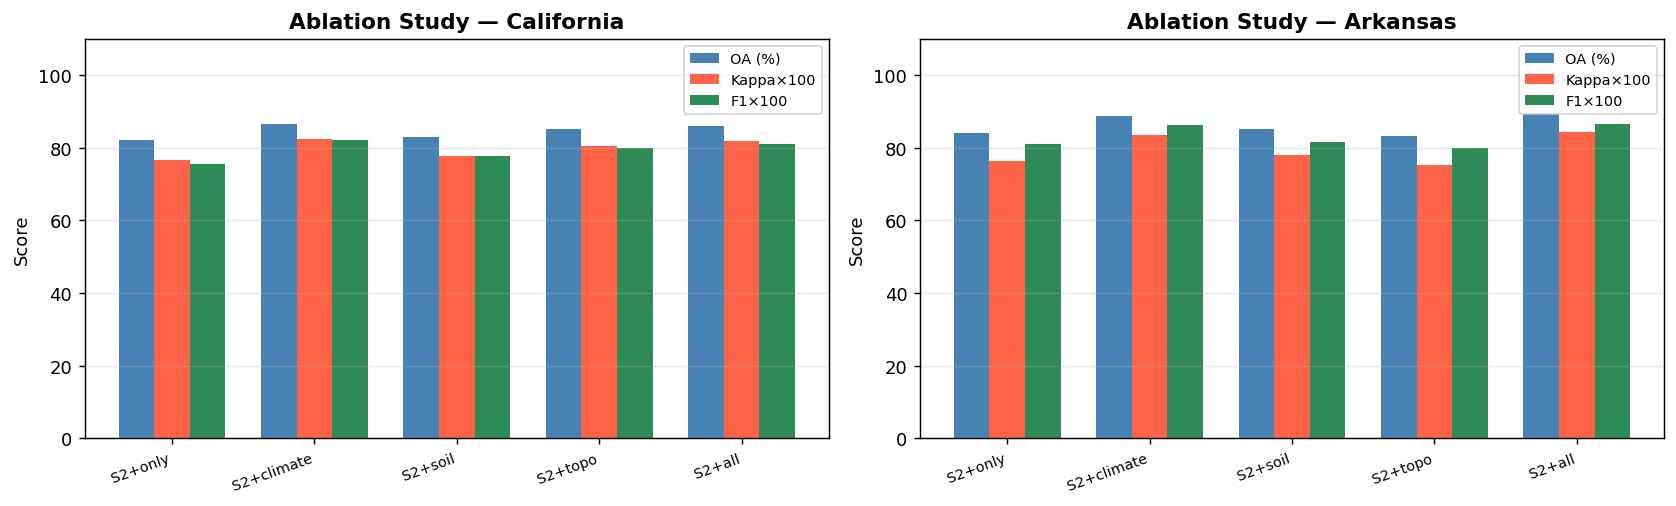

In [10]:
def plot_ablation_table(results_CA, results_AR, configs):
    rows = []
    for cfg in configs:
        ca = results_CA[cfg]
        ar = results_AR[cfg]
        rows.append({
            'Configuration': cfg.replace('_', ' '),
            'CA — OA (%)' : f"{ca['OA']:.2f}",
            'CA — Kappa'  : f"{ca['Kappa']:.3f}",
            'CA — F1'     : f"{ca['F1']:.3f}",
            'AR — OA (%)' : f"{ar['OA']:.2f}",
            'AR — Kappa'  : f"{ar['Kappa']:.3f}",
            'AR — F1'     : f"{ar['F1']:.3f}",
        })
    df = pd.DataFrame(rows)
    print('\n=== Ablation Study — Résultats ===')
    print(df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    x      = np.arange(len(configs))
    labels = [c.replace('S2_', 'S2+').replace('_only', ' seul') for c in configs]
    w      = 0.25

    for ax, res, region in zip(axes, [results_CA, results_AR], ['California', 'Arkansas']):
        oa    = [res[c]['OA']       for c in configs]
        kappa = [res[c]['Kappa']*100 for c in configs]
        f1    = [res[c]['F1']*100    for c in configs]
        ax.bar(x - w, oa,    w, label='OA (%)',    color='steelblue')
        ax.bar(x,     kappa, w, label='Kappa×100', color='tomato')
        ax.bar(x + w, f1,    w, label='F1×100',    color='seagreen')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
        ax.set_ylabel('Score')
        ax.set_title(f'Ablation Study — {region}', fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 110)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'ablation_study.png', dpi=150, bbox_inches='tight')
    plt.show()
    return df


df_ablation = plot_ablation_table(results_CA, results_AR, CONFIGS)

## 📊 ÉTAPE 7 — Matrices de confusion (baseline vs meilleure config)

Meilleure config CA : S2_climate  (Kappa=0.825)
Meilleure config AR : S2_all  (Kappa=0.843)


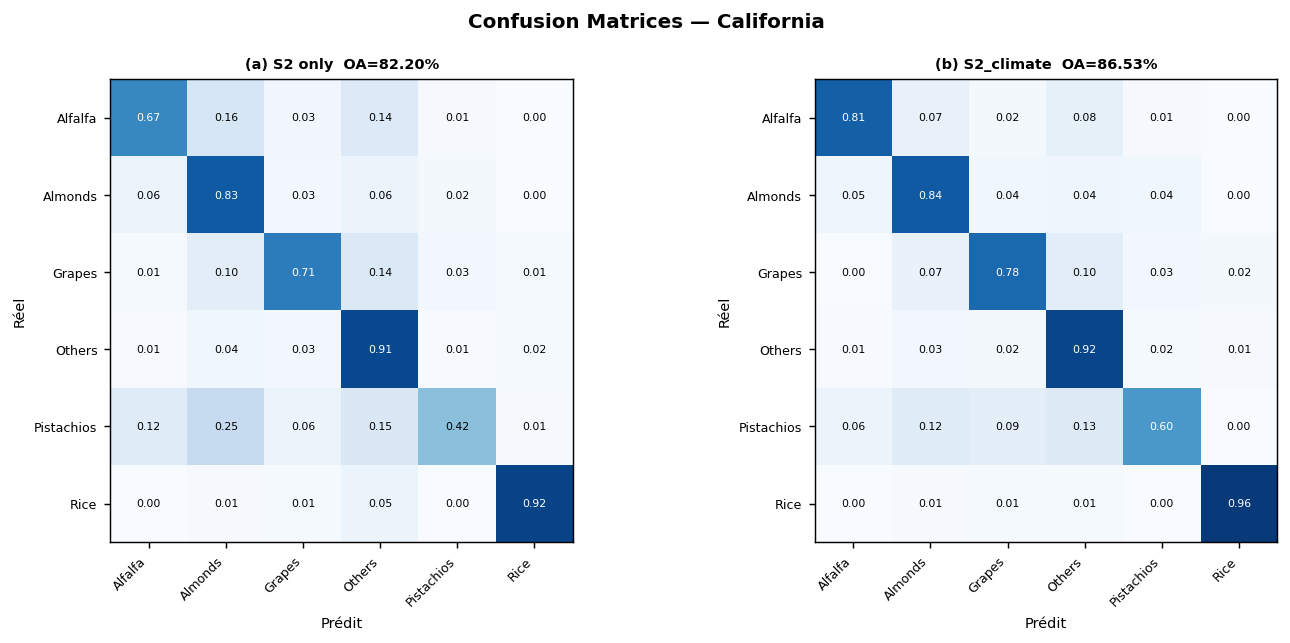

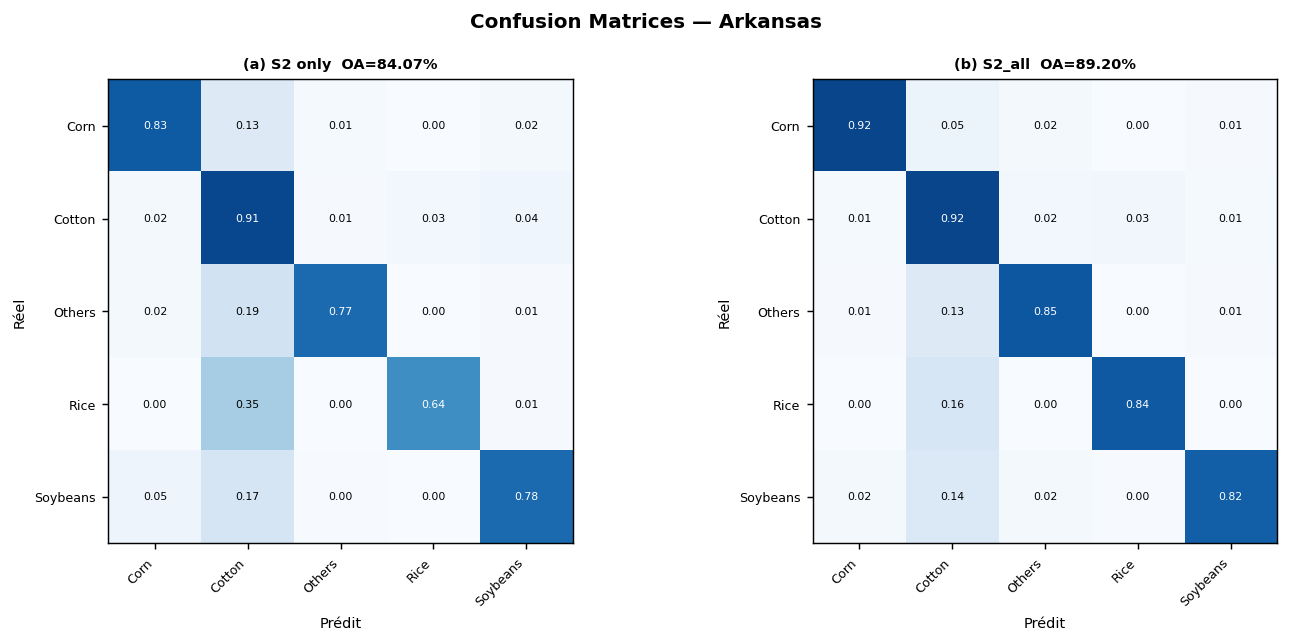

In [11]:
def plot_confusion_matrix(y_true, y_pred, classes, title='', ax=None):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    n  = len(classes)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.5))
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(classes, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(classes, fontsize=7)
    ax.set_xlabel('Prédit', fontsize=8); ax.set_ylabel('Réel', fontsize=8)
    ax.set_title(title, fontsize=8, fontweight='bold')
    for i in range(n):
        for j in range(n):
            c = 'white' if cm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=6, color=c)


best_ca = max(CONFIGS, key=lambda c: results_CA[c]['Kappa'])
best_ar = max(CONFIGS, key=lambda c: results_AR[c]['Kappa'])
print(f'Meilleure config CA : {best_ca}  (Kappa={results_CA[best_ca]["Kappa"]:.3f})')
print(f'Meilleure config AR : {best_ar}  (Kappa={results_AR[best_ar]["Kappa"]:.3f})')

# California
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_confusion_matrix(
    results_CA['S2_only']['y_true'], results_CA['S2_only']['pred'],
    le_CA.classes_,
    title=f'(a) S2 only  OA={results_CA["S2_only"]["OA"]:.2f}%', ax=axes[0])
plot_confusion_matrix(
    results_CA[best_ca]['y_true'], results_CA[best_ca]['pred'],
    le_CA.classes_,
    title=f'(b) {best_ca}  OA={results_CA[best_ca]["OA"]:.2f}%', ax=axes[1])
plt.suptitle('Confusion Matrices — California', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_ca_part2.png', dpi=150, bbox_inches='tight')
plt.show()

# Arkansas
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_confusion_matrix(
    results_AR['S2_only']['y_true'], results_AR['S2_only']['pred'],
    le_AR.classes_,
    title=f'(a) S2 only  OA={results_AR["S2_only"]["OA"]:.2f}%', ax=axes[0])
plot_confusion_matrix(
    results_AR[best_ar]['y_true'], results_AR[best_ar]['pred'],
    le_AR.classes_,
    title=f'(b) {best_ar}  OA={results_AR[best_ar]["OA"]:.2f}%', ax=axes[1])
plt.suptitle('Confusion Matrices — Arkansas', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_ar_part2.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔥 ÉTAPE 8 — Grad-CAM : Visualisation des features importantes (Style Paper 1)

**Inspiré de la Figure 9 du Paper 1 (Wang et al., 2021)** : heatmap 2D (bandes spectrales × temps) montrant quelles bandes et quelles dates le modèle regarde le plus pour chaque culture.

- Rouge/chaud = forte attention → features importantes pour la classification
- Bleu/froid = faible attention → features ignorées

Permet d'interpréter le modèle : valide-t-il la phénologie connue des cultures ?

In [ ]:
import torch.nn.functional as F

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 8 — Grad-CAM style Figure 9 (Wang et al., 2021)
#
# Résumé des dimensions par configuration :
#   S2_only    : 10 bandes × 36 dates = 360  features
#   S2_climate : 13 bandes × 36 dates = 468  features  (+Temp, Precip, Dewpoint)
#   S2_soil    : 13 bandes × 36 dates = 468  features  (+pH, OC, Texture)
#   S2_topo    : 12 bandes × 36 dates = 432  features  (+Elevation, Landforms)
#   S2_all     : 18 bandes × 36 dates = 648  features  (+Temp,Precip,Dew,pH,OC,Tex,Elev,LF)
# ═══════════════════════════════════════════════════════════════════════════

# ── Noms de bandes par configuration ────────────────────────────────────────
S2_BASE_BANDS = ['Blue', 'Green', 'Red',
                  'Red Edge 1', 'Red Edge 2', 'Red Edge 3',
                  'NIR', 'Red Edge 4', 'SWIR 1', 'SWIR 2']

EXTRA_BANDS = {
    'S2_only'   : [],
    'S2_climate': ['Température', 'Précip.', 'Point rosée'],
    'S2_soil'   : ['pH', 'Carb. org.', 'Texture'],
    'S2_topo'   : ['Élévation', 'Landforms'],
    'S2_all'    : ['Temp.', 'Précip.', 'Rosée', 'pH', 'OC', 'Texture', 'Élév.', 'LF'],
}

def get_band_names(config_name):
    return S2_BASE_BANDS + EXTRA_BANDS.get(config_name, [])


def compute_gradcam_per_class(model, datasets, config_name, device,
                               le, n_samples_per_class=50):
    """
    Calcule l'importance des features (Input Gradient × Input) par classe.
    Approche : gradient intégré simplifié (SmoothGrad-like) via gradient de l'entrée.

    Retourne : {class_name : np.array (N_DATES, n_bands_total)}
    """
    d             = datasets[config_name]
    n_bands_total = d['n_bands_total']
    X_test        = d['X_test']
    y_test        = d['y_test']

    grad_cam_dict = {}
    model.eval()

    for cls_idx, cls_name in enumerate(le.classes_):
        mask  = (y_test == cls_idx)
        X_cls = X_test[mask][:n_samples_per_class]
        if len(X_cls) == 0:
            continue

        cam_accum = np.zeros((N_DATES, n_bands_total), dtype=np.float32)

        for i in range(len(X_cls)):
            x = torch.from_numpy(X_cls[i:i+1]).to(device).float()
            x.requires_grad_(True)

            logits = model(x)                          # (1, C)
            score  = logits[0, cls_idx]
            model.zero_grad()
            score.backward()

            # Gradient × Input (Saliency map)
            grad_inp = x.grad.cpu().numpy()[0]         # (N_DATES * n_bands_total,)
            inp_val  = X_cls[i]                        # (N_DATES * n_bands_total,)

            saliency = np.abs(grad_inp * inp_val)      # element-wise
            saliency = saliency.reshape(N_DATES, n_bands_total)
            saliency /= (saliency.max() + 1e-8)        # normalise [0, 1]

            cam_accum += saliency

        grad_cam_dict[cls_name] = cam_accum / max(len(X_cls), 1)

    return grad_cam_dict


def plot_gradcam_figure9(grad_cam_dict, config_name, region_label,
                          n_bands_total, save_path=None):
    """
    Reproduit la Figure 9 du Paper 1 (Wang et al., 2021) :
    Grille de heatmaps 2D par culture :
      - Axe X = Day of Year (36 timesteps)
      - Axe Y = Bandes spectrales + covariables (bas→haut)
      - Couleur chaude (rouge/jaune) = forte importance
      - Couleur froide (bleu) = faible importance
    """
    band_names = get_band_names(config_name)[:n_bands_total]
    classes    = list(grad_cam_dict.keys())
    n_cls      = len(classes)

    # Axe X : Day of Year uniformément réparti sur 365 jours
    doy_axis = [int(i * 365 / N_DATES) + 1 for i in range(N_DATES)]

    # Hauteur figure proportionnelle au nombre de bandes
    fig_h = max(4.0, n_bands_total * 0.35 + 1.5)
    fig, axes = plt.subplots(1, n_cls,
                              figsize=(3.2 * n_cls + 0.8, fig_h),
                              squeeze=False)

    title_cfg = config_name.replace('S2_only', 'S2 seul').replace('S2_', 'S2 + ')
    fig.suptitle(
        f'Importance des features (style Fig.9, Wang et al. 2021)\n'
        f'{region_label} — Configuration : {title_cfg}  '
        f'({n_bands_total} bandes × {N_DATES} dates = {n_bands_total*N_DATES} features)',
        fontsize=10, fontweight='bold'
    )

    im_ref = None
    for j, cls_name in enumerate(classes):
        ax  = axes[0, j]
        cam = grad_cam_dict[cls_name]        # (N_DATES, n_bands_total)

        # Transpose : affiche bandes en Y, dates en X (comme Paper 1)
        cam_T = cam.T                        # (n_bands_total, N_DATES)

        im = ax.imshow(
            cam_T, aspect='auto', cmap='RdYlBu_r',
            vmin=0, vmax=cam_T.max(),
            extent=[doy_axis[0], doy_axis[-1], -0.5, n_bands_total - 0.5]
        )
        im_ref = im

        ax.set_title(f'({chr(97 + j)}) {cls_name}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Day of Year', fontsize=8)

        if j == 0:
            ax.set_ylabel('Bandes', fontsize=8)
            ax.set_yticks(range(n_bands_total))
            ax.set_yticklabels(band_names, fontsize=6.5)
        else:
            ax.set_yticks([])

        ax.set_xticks([1, 90, 180, 270, 360])
        ax.set_xticklabels(['1', '90', '180', '270', '360'], fontsize=7)
        ax.tick_params(axis='x', labelsize=7)

        # Ligne verticale DOY 180 (milieu d'année) — référence phénologique
        ax.axvline(180, color='white', linestyle='--', lw=0.8, alpha=0.6)

        # Séparation visuelle S2 / covariables
        if n_bands_total > 10:
            ax.axhline(9.5, color='white', linestyle='-', lw=1.2, alpha=0.8)
            if j == 0:
                ax.text(-8, 4.5, 'S2', fontsize=6, color='white',
                         rotation=90, va='center', ha='right', fontweight='bold')
                ax.text(-8, 10.5, 'Cov.', fontsize=6, color='white',
                         rotation=90, va='center', ha='right', fontweight='bold')

    # Colorbar commune
    if im_ref is not None:
        cbar_ax = fig.add_axes([0.92, 0.15, 0.014, 0.65])
        cb = fig.colorbar(im_ref, cax=cbar_ax)
        cb.set_label('Importance', fontsize=8)
        cb.ax.yaxis.set_ticks([])
        cb.ax.text(0.5, 1.03, 'Haute', ha='center', fontsize=7,
                   transform=cb.ax.transAxes, color='#D32F2F')
        cb.ax.text(0.5, -0.05, 'Basse', ha='center', fontsize=7,
                   transform=cb.ax.transAxes, color='#1565C0')

    plt.subplots_adjust(right=0.90, wspace=0.05)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Sauvegardé : {save_path.name}')
    plt.show()


# ── Tableau récap des dimensions ──────────────────────────────────────────────
print('=== Récapitulatif des dimensions par configuration ===')
print(f'{"Config":<15} {"N bandes":>8} {"N dates":>8} {"N features":>10}')
print('-' * 45)
config_bands = {'S2_only': 10, 'S2_climate': 13, 'S2_soil': 13,
                'S2_topo': 12, 'S2_all': 18}
for cfg, nb_ in config_bands.items():
    print(f'{cfg:<15} {nb_:>8} {N_DATES:>8} {nb_*N_DATES:>10}')

# ── Calcul et affichage Grad-CAM ──────────────────────────────────────────────
print('\n=== Grad-CAM — style Figure 9 (Paper 1) ===')
print('(Train Loss ✅  Val Loss ✅  Train Acc ✅  Val Acc ✅ déjà tracés Étape 5b)')
print()

for cfg in ['S2_only', 'S2_all']:
    n_bands_CA = datasets_CA[cfg]['n_bands_total']
    n_bands_AR = datasets_AR[cfg]['n_bands_total']

    print(f'--- California | {cfg} ({n_bands_CA} bandes × {N_DATES} = {n_bands_CA*N_DATES} features) ---')
    gc_CA = compute_gradcam_per_class(models_CA[cfg], datasets_CA, cfg,
                                       DEVICE, le_CA, n_samples_per_class=40)
    plot_gradcam_figure9(gc_CA, cfg, 'California', n_bands_CA,
                          save_path=PROCESSED_DIR / f'gradcam_CA_{cfg}.png')

    print(f'--- Arkansas | {cfg} ({n_bands_AR} bandes × {N_DATES} = {n_bands_AR*N_DATES} features) ---')
    gc_AR = compute_gradcam_per_class(models_AR[cfg], datasets_AR, cfg,
                                       DEVICE, le_AR, n_samples_per_class=40)
    plot_gradcam_figure9(gc_AR, cfg, 'Arkansas', n_bands_AR,
                          save_path=PROCESSED_DIR / f'gradcam_AR_{cfg}.png')

print('\n✅ Grad-CAM terminé')

# ── Décommenter pour toutes les configs ──────────────────────────────────────
# for cfg in CONFIGS:
#     for datasets, models, le, region, tag in [
#         (datasets_CA, models_CA, le_CA, 'California', 'CA'),
#         (datasets_AR, models_AR, le_AR, 'Arkansas',   'AR'),
#     ]:
#         nb_  = datasets[cfg]['n_bands_total']
#         gc   = compute_gradcam_per_class(models[cfg], datasets, cfg, DEVICE, le)
#         plot_gradcam_figure9(gc, cfg, region, nb_,
#                              save_path=PROCESSED_DIR / f'gradcam_{tag}_{cfg}.png')


## 💾 Sauvegarde des résultats

In [12]:
# ── 1. Tableau ablation ───────────────────────────────────────────────────────
df_ablation.to_csv(PROCESSED_DIR / 'ablation_results.csv', index=False)
print(f'✅ Tableau ablation : {PROCESSED_DIR}/ablation_results.csv')

# ── 2. Modèles .pth ───────────────────────────────────────────────────────────
for cfg in CONFIGS:
    torch.save(models_CA[cfg].state_dict(), MODEL_DIR / f'part2_CA_{cfg}.pth')
    torch.save(models_AR[cfg].state_dict(), MODEL_DIR / f'part2_AR_{cfg}.pth')
print(f'✅ Modèles         : {MODEL_DIR}/part2_*.pth')

# ── 3. CSV enrichis — un fichier par config × région ─────────────────────────
# Chaque CSV contient :
#   - toutes les features enrichies (flatten : n_bandes_total × 36 colonnes)
#   - la colonne 'crop_label' (nom de la classe)
#   - la colonne 'split'  (train / val / test)
#   - la colonne 'y'      (label encodé)
#   - la colonne 'pred'   (prédiction du modèle sur TOUT le dataset)

def save_enriched_csv(csv_path, datasets, models, le, results, label_map,
                       region_tag, configs, processed_dir, device):
    """
    Pour chaque config :
      1. Recharge le CSV source pour récupérer crop_label & split
      2. Concatène train+val+test dans le bon ordre
      3. Ajoute les features enrichies + prédictions
      4. Sauvegarde dans processed_dir/enriched_{region_tag}_{config}.csv
    """
    # Recharge le CSV source pour avoir crop_label et split
    df_src = pd.read_csv(csv_path)
    if 'label' in df_src.columns and 'crop_label' not in df_src.columns:
        df_src = df_src.rename(columns={'label': 'crop_label'})
    if label_map is not None:
        df_src['crop_label'] = df_src['crop_label'].map(label_map).fillna('Others')

    # Recrée le split si absent (même seed → même résultat)
    le_tmp = LabelEncoder()
    df_src['y'] = le_tmp.fit_transform(df_src['crop_label'])
    if 'split' not in df_src.columns:
        idx   = df_src.index.values
        y_all = df_src['y'].values
        idx_tr, idx_tmp2, _, y_tmp2 = train_test_split(
            idx, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all)
        idx_va, idx_te = train_test_split(
            idx_tmp2, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp2)
        df_src['split'] = 'train'
        df_src.loc[idx_va, 'split'] = 'val'
        df_src.loc[idx_te, 'split'] = 'test'

    for cfg in configs:
        d     = datasets[cfg]
        model = models[cfg]
        n_b   = d['n_bands_total']

        # Concatène train + val + test dans l'ordre original
        X_all = np.concatenate([d['X_train'], d['X_val'], d['X_test']], axis=0)
        y_all = np.concatenate([d['y_train'], d['y_val'], d['y_test']], axis=0)

        # Prédictions sur tout le dataset
        model.eval()
        with torch.no_grad():
            pred_all = model(
                torch.from_numpy(X_all).to(device)
            ).argmax(1).cpu().numpy()

        # Noms de colonnes : B1_t0 … Bk_tN + covariables
        n_features = X_all.shape[1]
        feat_names = [f'feat_{i}' for i in range(n_features)]

        df_out = pd.DataFrame(X_all, columns=feat_names)

        # Réordonne les index train/val/test → ordre original du CSV
        tr_mask = df_src['split'] == 'train'
        va_mask = df_src['split'] == 'val'
        te_mask = df_src['split'] == 'test'

        orig_order = np.concatenate([
            df_src.index[tr_mask].values,
            df_src.index[va_mask].values,
            df_src.index[te_mask].values,
        ])
        df_out.index = orig_order
        df_out       = df_out.sort_index()        # remet dans l'ordre du CSV source

        # Réordonne y et pred de la même façon
        reorder = np.argsort(orig_order)
        y_sorted    = y_all[reorder]
        pred_sorted = pred_all[reorder]

        df_out.insert(0, 'crop_label', df_src['crop_label'].values)
        df_out.insert(1, 'split',      df_src['split'].values)
        df_out.insert(2, 'y',          y_sorted)
        df_out.insert(3, 'pred',       pred_sorted)
        df_out.insert(4, 'pred_label', le.inverse_transform(pred_sorted))
        df_out.insert(5, 'correct',    (y_sorted == pred_sorted).astype(int))

        out_path = processed_dir / f'enriched_{region_tag}_{cfg}.csv'
        df_out.to_csv(out_path, index=False)
        print(f'  [{region_tag}] {cfg:<15} → {out_path.name}  '
              f'({len(df_out)} lignes × {len(df_out.columns)} colonnes)')


print('\n=== Sauvegarde CSV enrichis — CALIFORNIA ===')
save_enriched_csv(CSV_CA, datasets_CA, models_CA, le_CA, results_CA,
                   LABEL_MAP_CA, 'CA', CONFIGS, PROCESSED_DIR, DEVICE)

print('\n=== Sauvegarde CSV enrichis — ARKANSAS ===')
save_enriched_csv(CSV_AR, datasets_AR, models_AR, le_AR, results_AR,
                   LABEL_MAP_AR, 'AR', CONFIGS, PROCESSED_DIR, DEVICE)

print('\n📁 Fichiers générés dans', PROCESSED_DIR)
for f in sorted(PROCESSED_DIR.glob('enriched_*.csv')):
    size_mb = f.stat().st_size / 1e6
    print(f'   {f.name}  ({size_mb:.1f} MB)')

print('\n🎉 Partie 2 terminée !')

✅ Tableau ablation : data\processed/ablation_results.csv
✅ Modèles         : models/part2_*.pth

=== Sauvegarde CSV enrichis — CALIFORNIA ===
  [CA] S2_only         → enriched_CA_S2_only.csv  (10000 lignes × 366 colonnes)
  [CA] S2_climate      → enriched_CA_S2_climate.csv  (10000 lignes × 474 colonnes)
  [CA] S2_soil         → enriched_CA_S2_soil.csv  (10000 lignes × 474 colonnes)
  [CA] S2_topo         → enriched_CA_S2_topo.csv  (10000 lignes × 438 colonnes)
  [CA] S2_all          → enriched_CA_S2_all.csv  (10000 lignes × 654 colonnes)

=== Sauvegarde CSV enrichis — ARKANSAS ===
  [AR] S2_only         → enriched_AR_S2_only.csv  (10000 lignes × 366 colonnes)
  [AR] S2_climate      → enriched_AR_S2_climate.csv  (10000 lignes × 474 colonnes)
  [AR] S2_soil         → enriched_AR_S2_soil.csv  (10000 lignes × 474 colonnes)
  [AR] S2_topo         → enriched_AR_S2_topo.csv  (10000 lignes × 438 colonnes)
  [AR] S2_all          → enriched_AR_S2_all.csv  (10000 lignes × 654 colonnes)

📁 Fichier